In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import pickle
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

# Veriyi yükle
df = pd.read_csv('../data/processed/olist_features.csv')
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])
df['order_date'] = pd.to_datetime(df['order_date'])

# Kategorik sütunları encode et
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
categorical_cols = ['customer_state', 'seller_state', 'seller_experience', 
                    'month_period', 'product_category_name_english']
for col in categorical_cols:
    df[col] = le.fit_transform(df[col].astype(str))

# Model için feature listesi
drop_cols = ['order_id', 'customer_id', 'product_id', 'seller_id',
             'order_purchase_timestamp', 'order_delivered_customer_date',
             'order_estimated_delivery_date', 'order_date', 'log_price']
target = 'log_price'
feature_cols = [col for col in df.columns if col not in drop_cols + [target, 'price']]

X = df[feature_cols]
y = df[target]

# Modeli yükle
with open('../outputs/lgbm_model.pkl', 'rb') as f:
    model = pickle.load(f)

print("Model ve veri yüklendi!")
print(f"Özellik sayısı: {len(feature_cols)}")

Model ve veri yüklendi!
Özellik sayısı: 41


In [3]:
# SHAP için örnek veri al (tüm veri çok yavaş olur)
sample_size = 1000
X_sample = X.sample(n=sample_size, random_state=42)

# SHAP Explainer oluştur
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_sample)

print(f"SHAP değerleri hesaplandı!")
print(f"Shape: {shap_values.shape}")

SHAP değerleri hesaplandı!
Shape: (1000, 41)


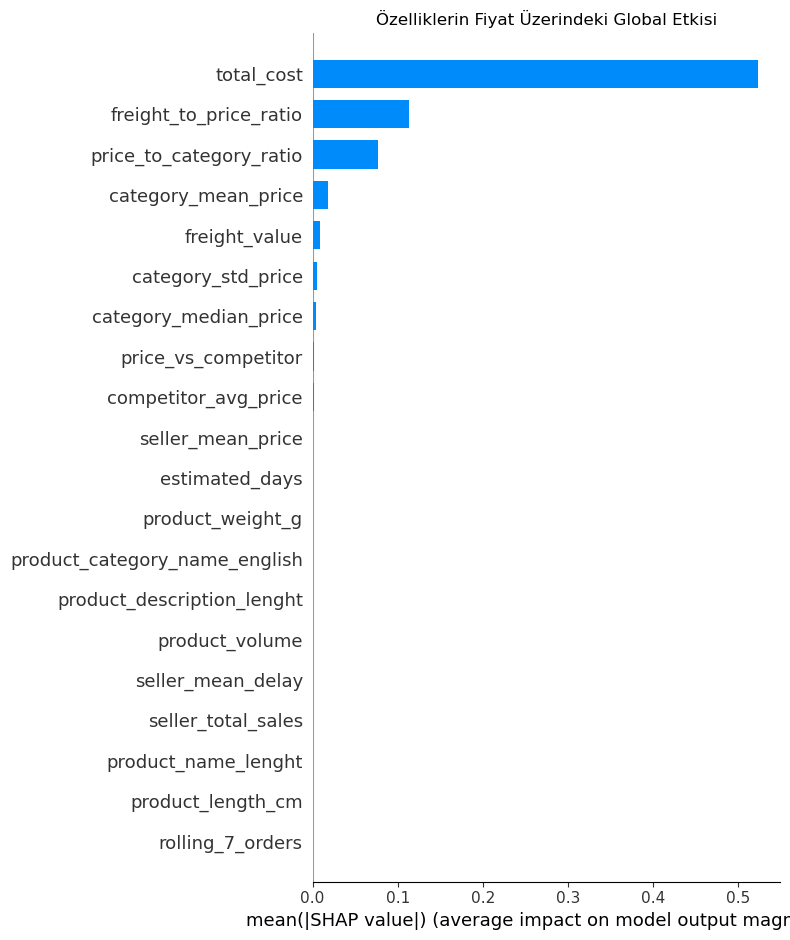

Grafik kaydedildi!


In [4]:
# 1. Global özellik önemi — hangi özellik fiyatı en çok etkiliyor?
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_sample, plot_type="bar", show=False)
plt.title("Özelliklerin Fiyat Üzerindeki Global Etkisi")
plt.tight_layout()
plt.savefig('../outputs/figures/shap_global.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafik kaydedildi!")

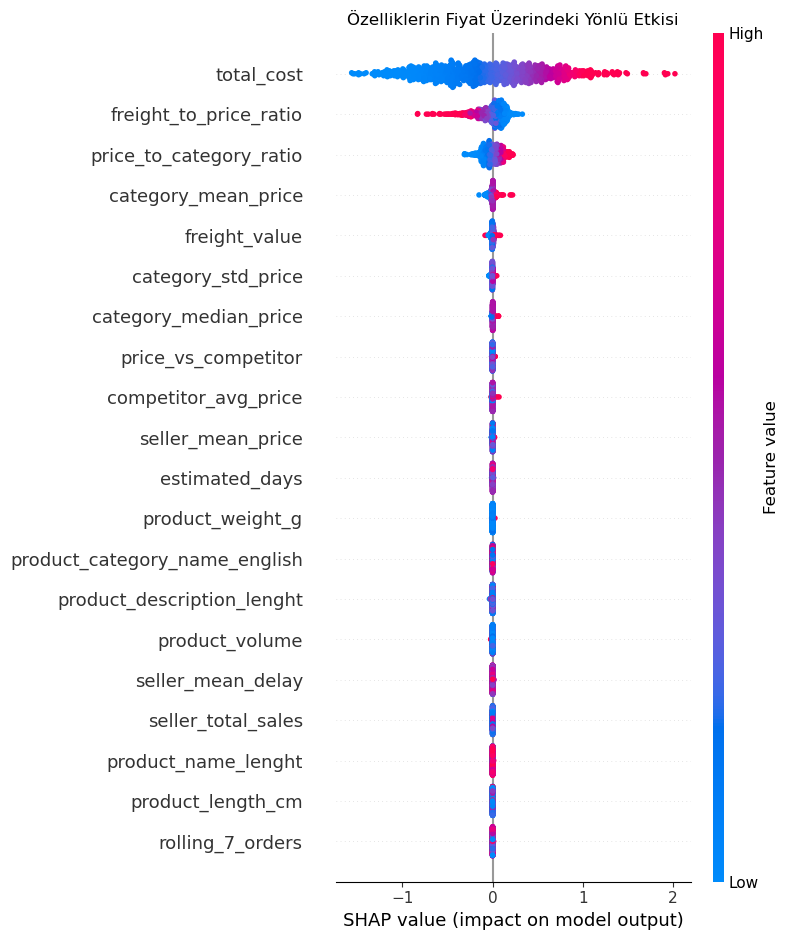

Grafik kaydedildi!


In [5]:
# 2. Beeswarm — her özelliğin yönünü göster
# Yüksek değer fiyatı artırıyor mu düşürüyor mu?
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_sample, show=False)
plt.title("Özelliklerin Fiyat Üzerindeki Yönlü Etkisi")
plt.tight_layout()
plt.savefig('../outputs/figures/shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafik kaydedildi!")

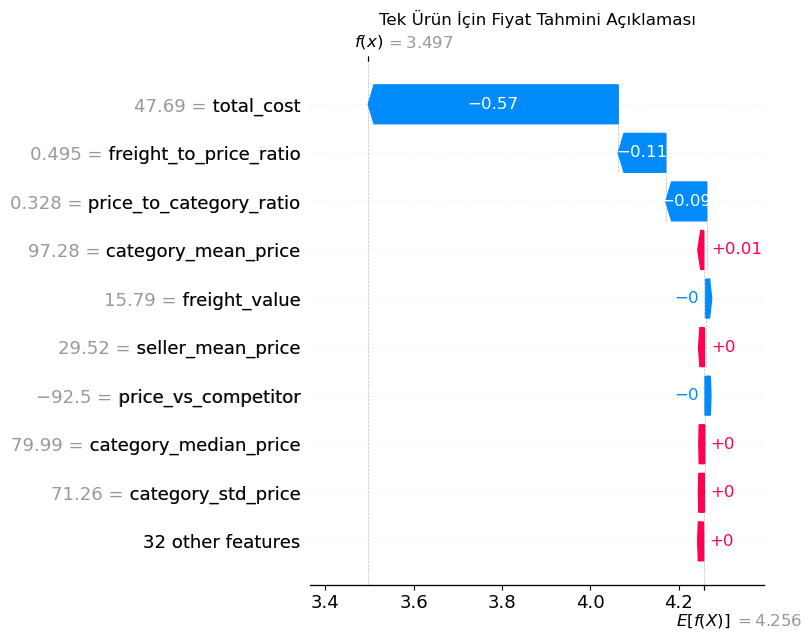

Gerçek fiyat: 31.90 BRL
Tahmin fiyat: 32.02 BRL


In [6]:
# 3. Waterfall — tek bir tahmin için açıklama
sample_idx = 0
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[sample_idx],
        base_values=explainer.expected_value,
        data=X_sample.iloc[sample_idx],
        feature_names=feature_cols
    ),
    show=False
)
plt.title("Tek Ürün İçin Fiyat Tahmini Açıklaması")
plt.tight_layout()
plt.savefig('../outputs/figures/shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()

# O ürünün gerçek fiyatı
real_price = np.expm1(y.iloc[X_sample.index[sample_idx]])
predicted_price = np.expm1(model.predict(X_sample.iloc[[sample_idx]])[0])
print(f"Gerçek fiyat: {real_price:.2f} BRL")
print(f"Tahmin fiyat: {predicted_price:.2f} BRL")